In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1.Data Cleaning and Preparation

In [2]:
df=pd.read_csv('cardiotocographic.csv')
df

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,73.0,0.5,43.000000,2.4,64.0,0.999926,2.000000
1,132.000000,0.006380,0.000000,0.006380,0.003190,0.0,0.0,17.0,2.1,0.000000,10.4,130.0,0.000000,1.000000
2,133.000000,0.003322,0.000000,0.008306,0.003322,0.0,0.0,16.0,2.1,0.000000,13.4,130.0,0.000000,1.000000
3,134.000000,0.002561,0.000000,0.007742,0.002561,0.0,0.0,16.0,2.4,0.000000,23.0,117.0,1.000000,1.000000
4,131.948232,0.006515,0.000000,0.008143,0.000000,0.0,0.0,16.0,2.4,0.000000,19.9,117.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2121,140.000000,0.000000,0.961268,0.007426,0.000000,0.0,0.0,79.0,0.2,25.000000,7.2,40.0,0.000000,2.000000
2122,140.000000,0.000775,0.000000,0.006979,0.000000,0.0,0.0,78.0,0.4,22.000000,7.1,66.0,1.000000,2.000000
2123,140.000000,0.000980,0.000000,0.006863,0.000000,0.0,0.0,79.0,0.4,20.000000,6.1,67.0,1.000000,1.990464
2124,140.000000,0.000679,0.000000,0.006110,0.000000,0.0,0.0,78.0,0.4,27.000000,7.0,66.0,1.000000,2.000000


In [3]:
df.shape

(2126, 14)

In [4]:
df.size

29764

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB


In [6]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [7]:
df.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='object')

In [8]:
num_col=df.select_dtypes(include=['int','float']).columns
num_col

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='object')

## remove duplicates

In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

np.int64(0)

## missing series

In [12]:
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [13]:
df.fillna(df.mean(),inplace=True)

In [14]:
df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

## remove outliers

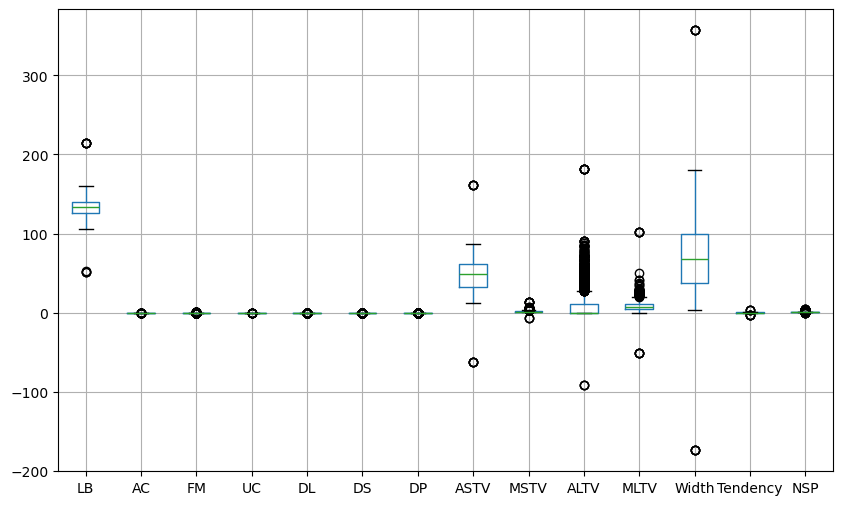

In [15]:
plt.figure(figsize=(10,6))
df.boxplot()
plt.show()

In [16]:
def outlier_capping(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1
    lower_extreme=Q1-1.5*IQR
    upper_extreme=Q3+1.5*IQR
    df[column]=df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(include=('int','float')):
    outlier_capping(df,col)


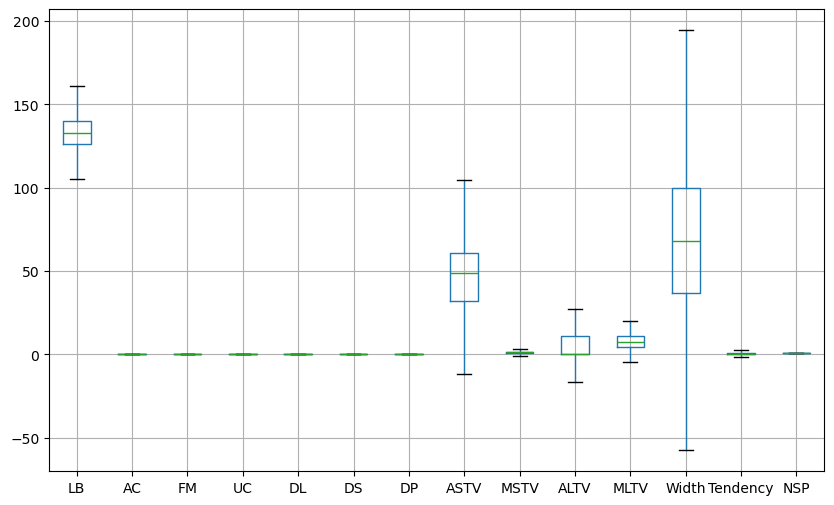

In [17]:
plt.figure(figsize=(10,6))
df.boxplot()
plt.show()

## 2.Statistical Summary

In [18]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.0,2124.0,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.0
mean,133.292103,0.003148,0.001570,0.004365,0.001772,0.0,0.0,46.998334,1.304554,6.697979,8.011618,70.352766,0.319966,1.0
std,9.926749,0.003827,0.002487,0.003001,0.002670,0.0,0.0,17.609911,0.781303,10.381254,5.046504,39.575996,0.621818,0.0
min,105.000000,-0.008418,-0.003853,-0.005158,-0.004938,0.0,0.0,-11.500000,-0.800000,-16.500000,-4.700000,-57.500000,-1.500000,1.0
25%,126.000000,0.000000,0.000000,0.001858,0.000000,0.0,0.0,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.0
50%,133.000000,0.001668,0.000000,0.004486,0.000000,0.0,0.0,49.000000,1.200000,0.000000,7.500000,68.000000,0.000000,1.0
75%,140.000000,0.005612,0.002568,0.006536,0.003292,0.0,0.0,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.0
max,161.000000,0.014030,0.006421,0.013552,0.008230,0.0,0.0,104.500000,3.200000,27.500000,20.100000,194.500000,2.500000,1.0


In [19]:
## mean
mean=pd.DataFrame({'mean':df.mean()})
mean

,mean
LB,133.292103
AC,0.003148
FM,0.001570
UC,0.004365
DL,0.001772
DS,0.000000
DP,0.000000
ASTV,46.998334
MSTV,1.304554
ALTV,6.697979


In [20]:
## median
median=pd.DataFrame({'median':df.median()})
median

,median
LB,133.000000
AC,0.001668
FM,0.000000
UC,0.004486
DL,0.000000
DS,0.000000
DP,0.000000
ASTV,49.000000
MSTV,1.200000
ALTV,0.000000


In [21]:
## standard deviation
std=pd.DataFrame({'std':df.std()})
std

,std
LB,9.926749
AC,0.003827
FM,0.002487
UC,0.003001
DL,0.002670
DS,0.000000
DP,0.000000
ASTV,17.609911
MSTV,0.781303
ALTV,10.381254


In [22]:
## interquartile
q1=df.quantile(0.25)
q3=df.quantile(0.75)
iqr=q3-q1
ca=pd.DataFrame({'iqr':iqr})
ca

,iqr
LB,14.000000
AC,0.005612
FM,0.002568
UC,0.004678
DL,0.003292
DS,0.000000
DP,0.000000
ASTV,29.000000
MSTV,1.000000
ALTV,11.000000


## 3.Data Visualization

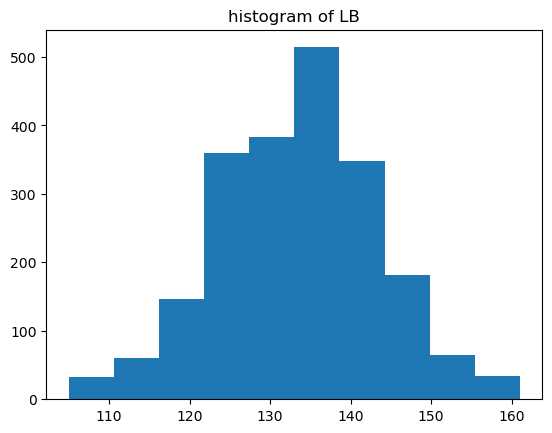

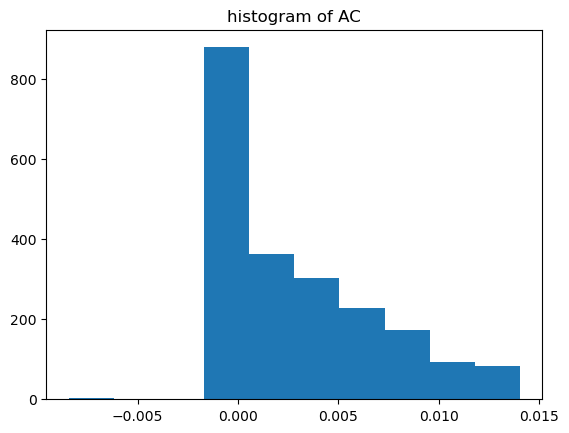

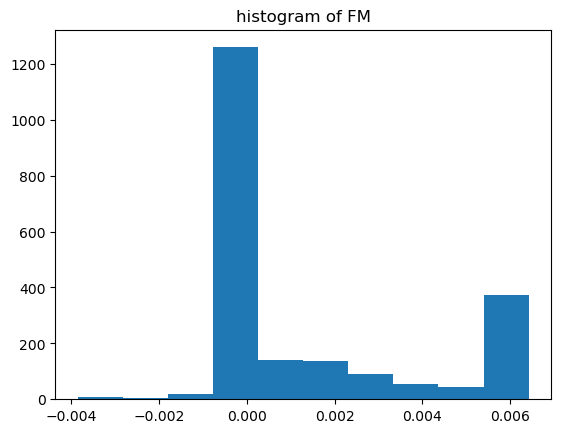

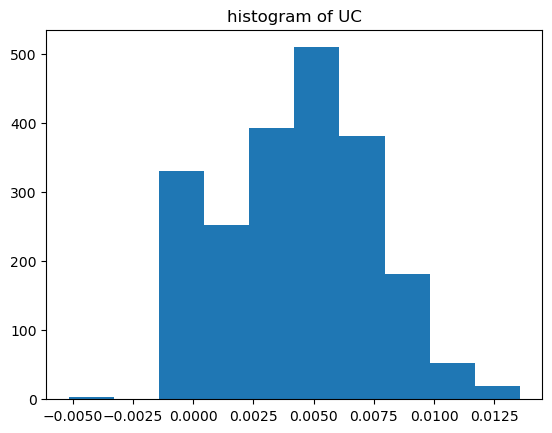

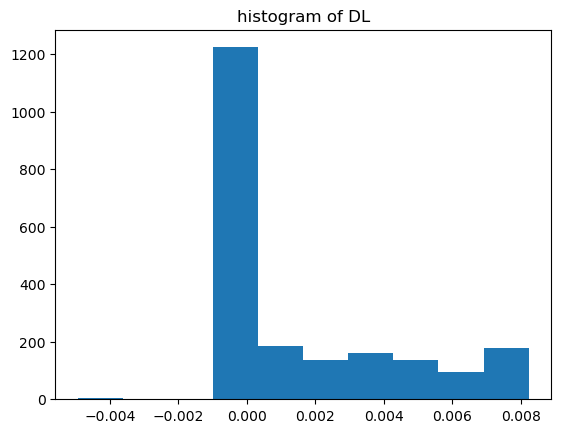

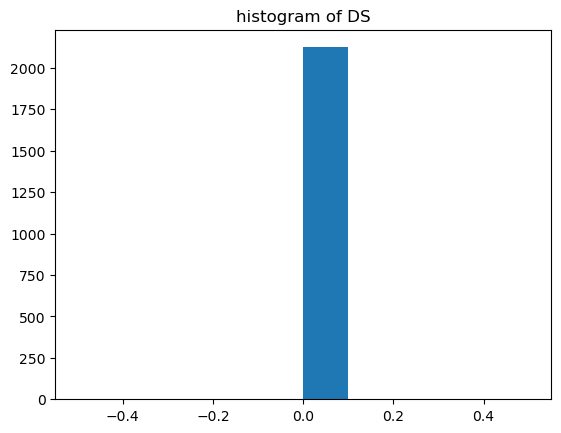

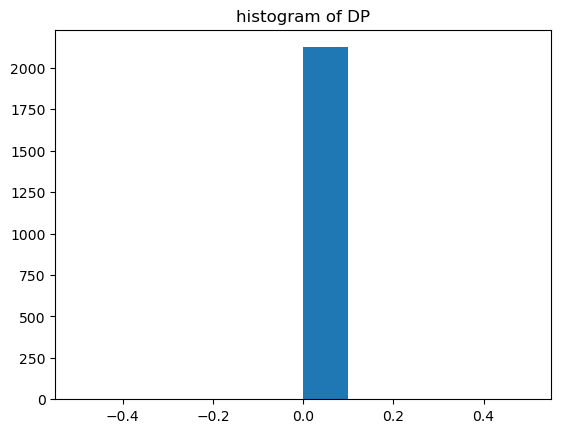

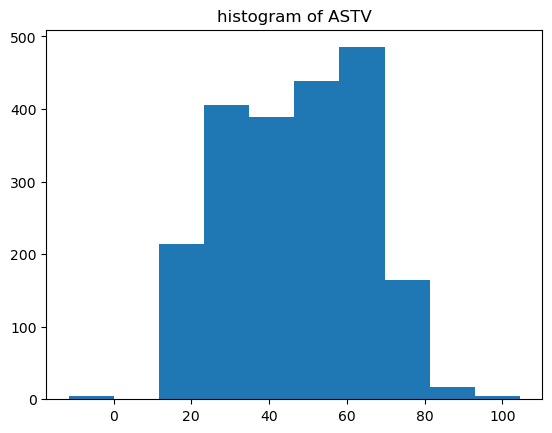

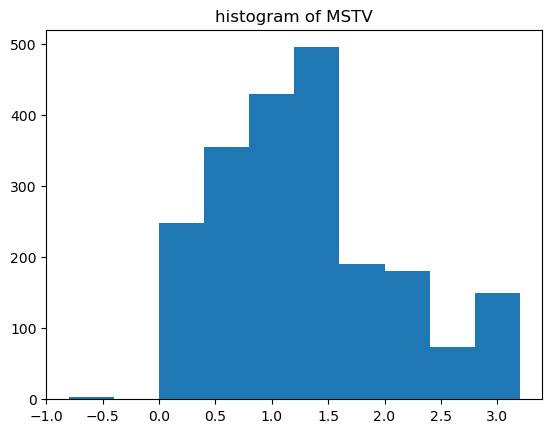

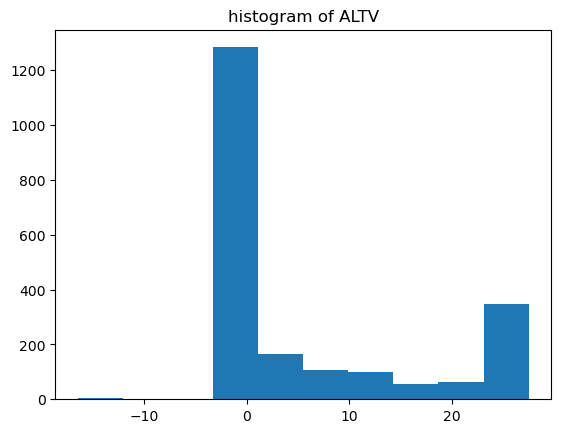

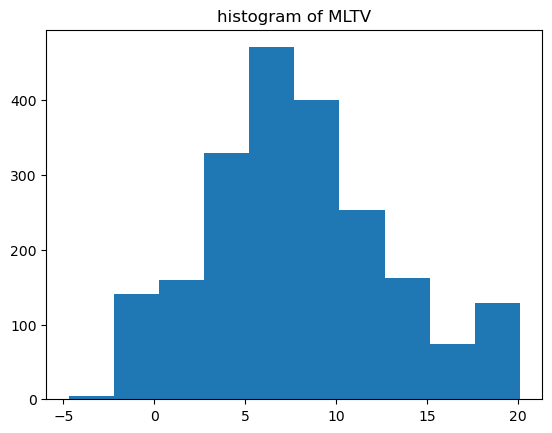

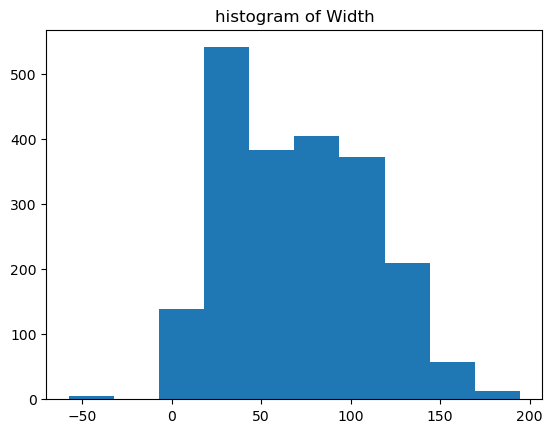

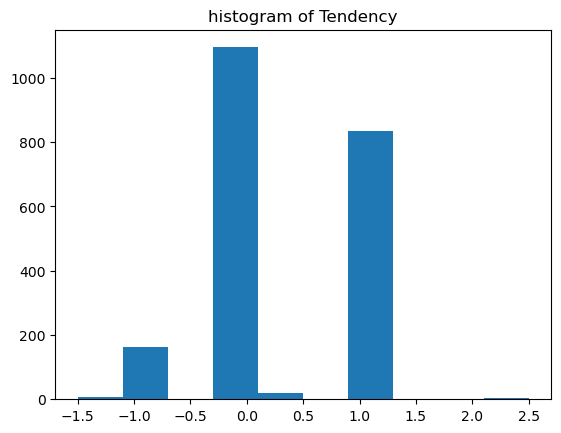

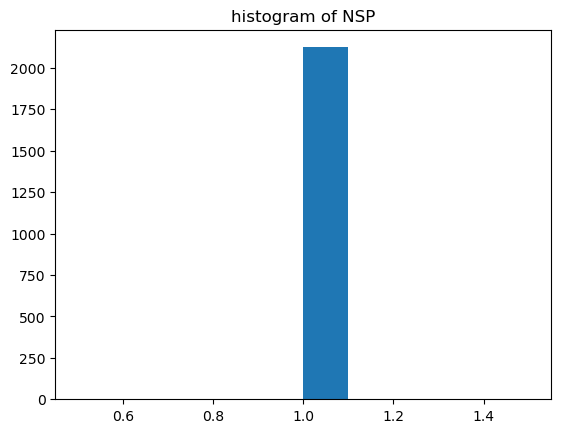

In [23]:
## histogram
for col in df:
    plt.hist(df[col])
    plt.title(f'histogram of {col}')
    plt.show()

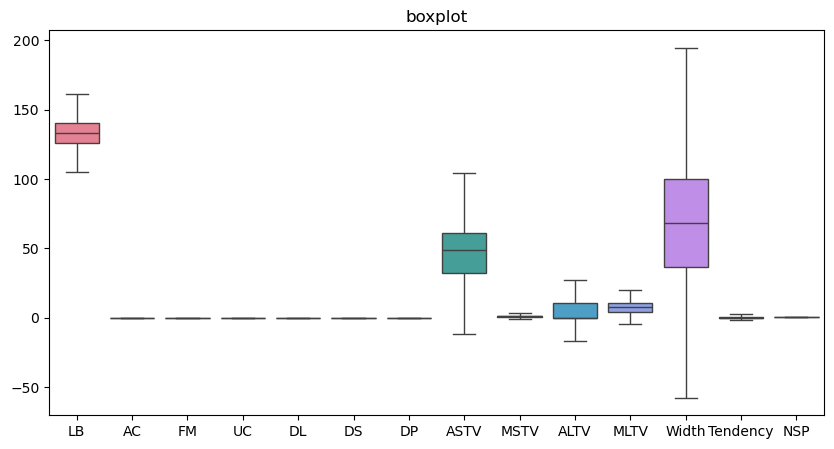

In [24]:
## boxplot
plt.figure(figsize=(10,5))
sns.boxplot(df)
plt.title('boxplot')
plt.show()

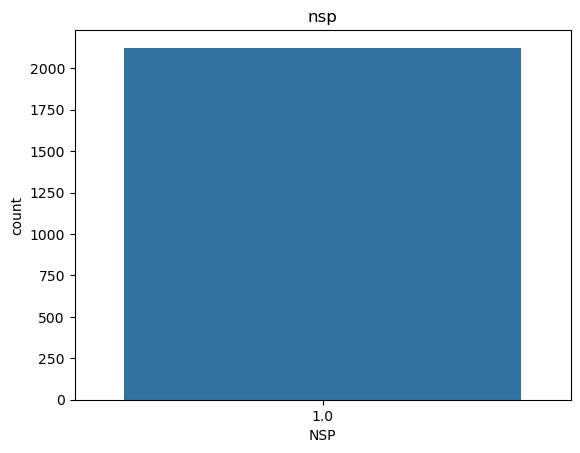

In [25]:
## barchart
sns.countplot(x='NSP',data=df)
plt.title('nsp')
plt.show()

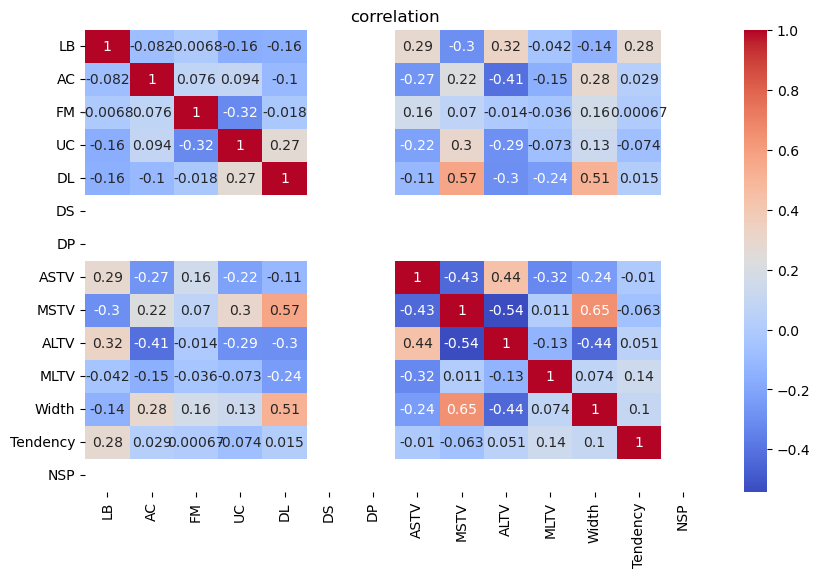

In [26]:
## correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('correlation')
plt.show()


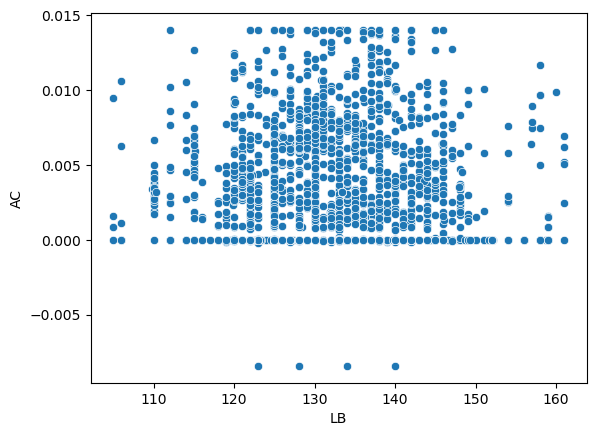

In [27]:
## scatterplot
sns.scatterplot(x='LB',y='AC',data=df)
plt.show()

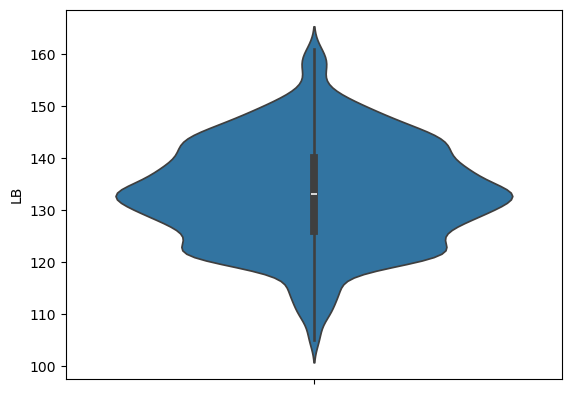

In [28]:
## violin plot
sns.violinplot(df['LB'])
plt.show()

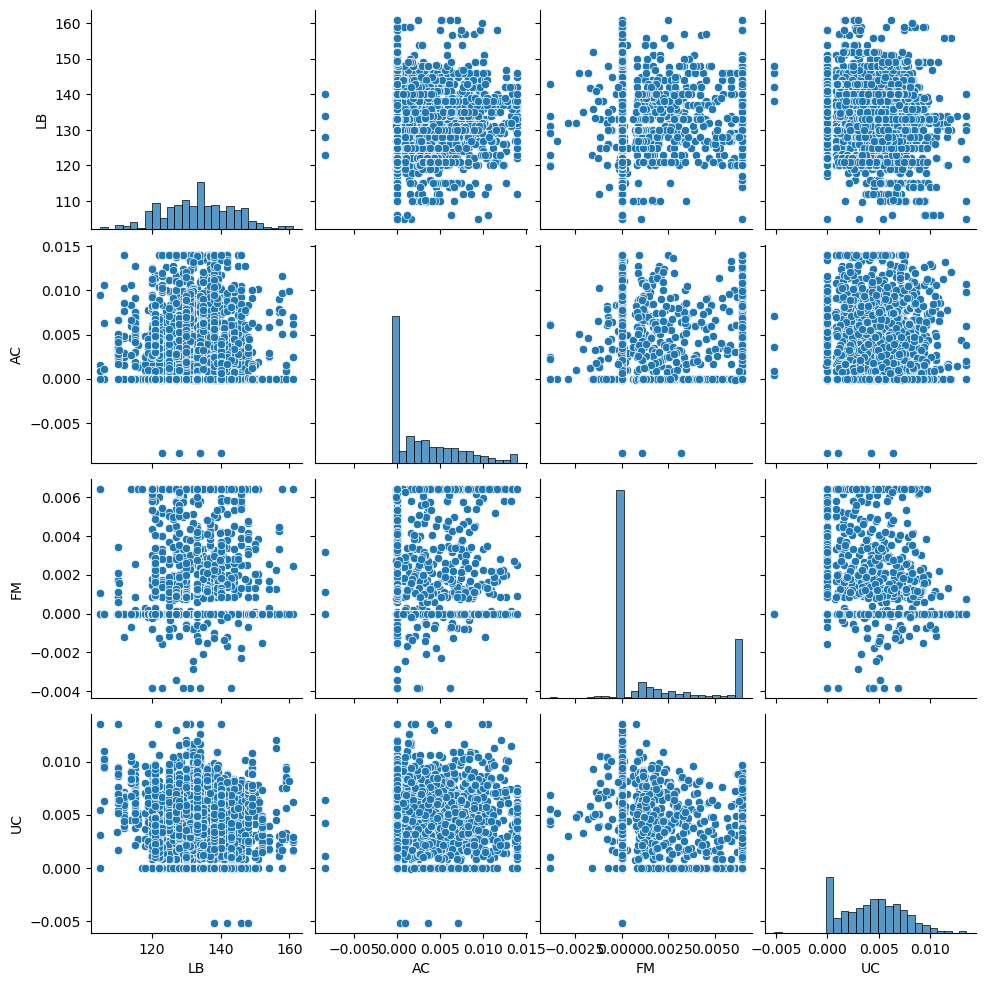

In [29]:
## pairplot
sns.pairplot(df[['LB','AC','FM','UC']])
plt.show()

## 4.Pattern Recognition and Insights

In [30]:
corr = df.corr(numeric_only=True)
print(corr['NSP'].sort_values(ascending=False))

LB         NaN
AC         NaN
FM         NaN
UC         NaN
DL         NaN
DS         NaN
DP         NaN
ASTV       NaN
MSTV       NaN
ALTV       NaN
MLTV       NaN
Width      NaN
Tendency   NaN
NSP        NaN
Name: NSP, dtype: float64


## 5.Conclusion